In [2]:
import os
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------- Project paths ----------
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../.."))
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
sys.path.append(SRC_DIR)

from dataprep import CLASSES, get_val_transforms
from resnet18.terraria_data import TerrariaBiomeDataset

# ---------- CSV and data folder ----------
CSV_PATH = os.path.join(PROJECT_ROOT, "data", "captures.csv")
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")

In [3]:
# Load full dataset, then only use validation split
full_dataset = TerrariaBiomeDataset(
    csv_path=CSV_PATH,
    root_dir=DATA_ROOT,
    transform=get_val_transforms()
)

# Optionally, you can replicate the 80/20 split used in training
val_size = int(0.2 * len(full_dataset))
val_dataset, _ = torch.utils.data.random_split(full_dataset, [val_size, len(full_dataset) - val_size])

val_dataset.dataset.transform = get_val_transforms()

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [4]:
import onnx
import onnxruntime as ort

ONNX_MODEL_PATH = os.path.join(PROJECT_ROOT, "src", "resnet18", "checkpoints", "resnet18_terraria.onnx")
sess = ort.InferenceSession(ONNX_MODEL_PATH, providers=[
    p for p in ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
    if p in ort.get_available_providers()
])

inp_name = sess.get_inputs()[0].name
out_name = sess.get_outputs()[0].name

print("ONNX model loaded with providers:", sess.get_providers())

*************** EP Error ***************
EP Error E:\_work\1\s\onnxruntime\python\onnxruntime_pybind_state.cc:539 onnxruntime::python::RegisterTensorRTPluginsAsCustomOps Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************
ONNX model loaded with providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']


In [5]:
MEAN = np.array([0.1473, 0.1647, 0.2079], dtype=np.float32)
STD  = np.array([0.1967, 0.2150, 0.2937], dtype=np.float32)

def prep_image(img):
    """
    Preprocess HxWx3 numpy array for ONNX model.
    Returns 1x3xHxW float32
    """
    x = img.astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = x.transpose(2,0,1)[None]  # HWC -> CHW and add batch
    return x

In [6]:
all_preds = []
all_labels = []

for img, label in val_loader:
    # Convert tensor to numpy, CHW -> HWC, float32
    img_np = img[0].permute(1,2,0).numpy().astype(np.float32)
    
    # If val_dataset already normalized, skip normalization here
    # just transpose to CHW and add batch
    input_onnx = img_np.transpose(2,0,1)[None]

    logits = sess.run([out_name], {inp_name: input_onnx})[0][0]
    pred = logits.argmax()
    all_preds.append(pred)
    all_labels.append(label.item())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy = (all_preds == all_labels).mean()
print(f"Validation accuracy (ONNX): {accuracy:.4f}")

Validation accuracy (ONNX): 0.4719


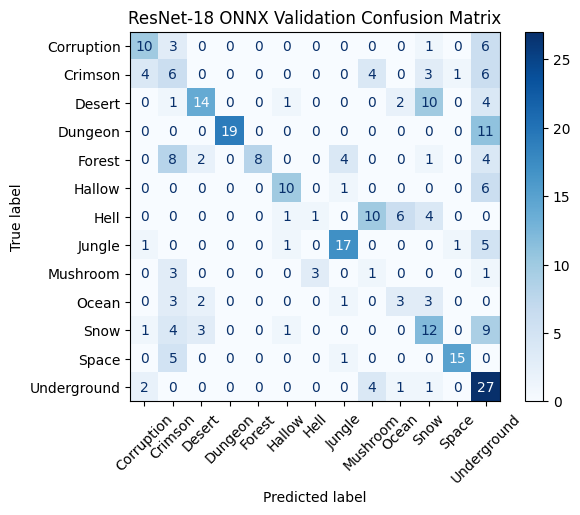

In [7]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(xticks_rotation=45, cmap=plt.cm.Blues)
plt.title("ResNet-18 ONNX Validation Confusion Matrix")
plt.show()